# Initializing

In [66]:
import warnings

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import importlib, model
importlib.reload(model)

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

# Base + Models
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV

# Imbalanced learning
from imblearn.pipeline import Pipeline
from imblearn.base import BaseSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

# Utils
from collections import Counter
from typing import Optional, Union, Literal, Iterable, Any, Dict

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
%matplotlib inline

# 

In [67]:
df = pd.read_csv("../data/historical.csv")
df.head()

,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
0,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-10,1,3.28,...,98,Formula,11,9,0,4.2,7.0,Yes,Yes,At Risk
1,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-11,2,3.35,...,99,Formula,11,5,2,10.6,NaN,No,No,At Risk
2,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-12,3,3.35,...,97,Breastfeeding,7,6,5,9.8,NaN,No,No,Healthy
3,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-13,4,3.48,...,97,Mixed,11,8,4,8.1,NaN,No,Yes,Healthy
4,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-14,5,3.50,...,96,Breastfeeding,11,7,1,11.6,NaN,No,Yes,At Risk


In [68]:
null_counts = df.isnull().sum()
print("Null values per column:\n", null_counts)

total_nulls = df.isnull().sum().sum()
print("Total null values in dataset:", total_nulls)

null_percentage = (df.isnull().mean() * 100).round(2)
print("Percentage of null values per column:\n", null_percentage)

Null values per column:
 baby_id                           0
name                              0
gender                            0
gestational_age_weeks             0
birth_weight_kg                   0
birth_length_cm                   0
birth_head_circumference_cm       0
date                              0
age_days                          0
weight_kg                         0
length_cm                         0
head_circumference_cm             0
temperature_c                     0
heart_rate_bpm                    0
respiratory_rate_bpm              0
oxygen_saturation                 0
feeding_type                      0
feeding_frequency_per_day         0
urine_output_count                0
stool_count                       0
jaundice_level_mg_dl              0
apgar_score                    2030
immunizations_done                0
reflexes_normal                   0
risk_level                        0
dtype: int64
Total null values in dataset: 2030
Percentage of null values p

In [69]:
model = joblib.load("../data/model.joblib")
model

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [71]:
# MinMax Scaling: age_days
# Standard Scaling is bad for ALL variable 

# df[num_cols].hist(bins=30, figsize=(15, 12))
# plt.tight_layout()
# plt.show()

In [72]:
target = df['risk_level']

df['date'] = pd.to_datetime(df['date'])
df['days_from_start'] = df.groupby('baby_id')['date'].transform(
    lambda x: (x - x.min()).dt.days
)
#df = df.drop(columns=['date'])

In [73]:
X, y = df.iloc[:, :-1], df.iloc[:, -1]

X_Train, X_test, y_Train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=target
)

X_train, X_val, y_train, y_val = train_test_split(
    X_Train, y_Train, test_size=0.2, random_state=0, stratify=y_Train
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (1344, 25)
X_val shape: (336, 25)


In [74]:
standard_features = ['gestational_age_weeks', 'birth_weight_kg', 'birth_length_cm', 'birth_head_circumference_cm', 
                     'weight_kg', 'length_cm', 'head_circumference_cm', 'temperature_c', 'heart_rate_bpm', 
                     'respiratory_rate_bpm', 'oxygen_saturation', 'feeding_frequency_per_day', 'urine_output_count', 
                     'stool_count']
minmax_features = ['age_days', 'days_from_start']
cat_features = ['baby_id', 'name', 'gender', 'feeding_type',
       'immunizations_done', 'reflexes_normal']


# Preprocessing the Data

In [ ]:
# --- Constants ---
DATE_COL = "date"
TARGET   = "risk_level"
DROP_COLS = ["apgar_score", "baby_id"]  # dropped upfront

# --- Train/Val split ---
X = df.drop(columns=[TARGET] + DROP_COLS)  # 'date' stays; no baby_id/apgar in X
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1234
)

# --- Model: end-to-end pipeline inside ML2Detector ---
model_est = model.ML2Detector(
    date_col=DATE_COL,    
    drop_cols=None,      
    classifier="logreg",      # "rf" | "logreg" | "balanced_rf" | "easy_ensemble"
    imbalance=None,       # e.g., "smote", "rus", "class_weight", etc.
    random_state=1234
)

# --- Fit & Evaluate ---
model_est.fit(X_train, y_train)
y_pred = model_est.predict(X_val)

from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pandas as pd

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}\n")

print("F1 (weighted):", f1_score(y_val, y_pred, average="weighted"))
print("\nClassification report:\n", classification_report(y_val, y_pred))
print("\nConfusion matrix:\n", pd.DataFrame(confusion_matrix(y_val, y_pred)))

X_train shape: (1680, 23)
X_val shape:   (420, 23)

F1 (weighted): 0.9122101691429747

Classification report:
               precision    recall  f1-score   support

     At Risk       0.70      0.62      0.66        56
     Healthy       0.94      0.96      0.95       364

    accuracy                           0.91       420
   macro avg       0.82      0.79      0.81       420
weighted avg       0.91      0.91      0.91       420


Confusion matrix:
     0    1
0  35   21
1  15  349


# Handling Class Imbalance

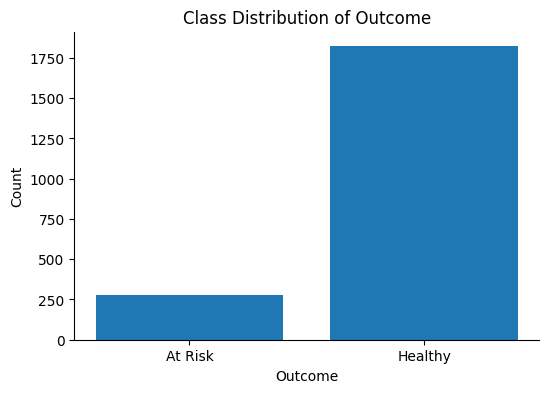

risk_level
At Risk     278
Healthy    1822
Name: count, dtype: int64


In [60]:
class_counts = df["risk_level"].value_counts().sort_index()

# Plot
plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution of Outcome")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()
print(class_counts)

In [64]:
POS_LABEL = "At Risk"  # <- change if needed

# --- 7 methods: 4 standard + 3 hybrid ---
pipelines = {
    # Standard
    "lr_class_weight" : make_model_pipeline(
        id_col=ID_COL, date_col=DATE_COL,
        classifier=LogisticRegression(max_iter=2000, random_state=1234),
        imbalance="class_weight"
    ),
    "ros_lr" : make_model_pipeline(
        id_col=ID_COL, date_col=DATE_COL,
        classifier=LogisticRegression(max_iter=2000, random_state=1234),
        imbalance="ros"
    ),
    "rus_lr" : make_model_pipeline(
        id_col=ID_COL, date_col=DATE_COL,
        classifier=LogisticRegression(max_iter=2000, random_state=1234),
        imbalance="rus"
    ),
    "smote_lr" : make_model_pipeline(
        id_col=ID_COL, date_col=DATE_COL,
        classifier=LogisticRegression(max_iter=2000, random_state=1234),
        imbalance="smote"
    ),

    # Hybrid
    "smoteenn_lr" : make_model_pipeline(
        id_col=ID_COL, date_col=DATE_COL,
        classifier=LogisticRegression(max_iter=2000, random_state=1234),
        imbalance="smoteenn"
    ),
    "smotetomek_rf" : make_model_pipeline(
        id_col=ID_COL, date_col=DATE_COL,
        classifier=RandomForestClassifier(n_estimators=500, random_state=1234, n_jobs=-1),
        imbalance="smotetomek"
    ),
    "cc_smote_lr" : make_model_pipeline(
        id_col=ID_COL, date_col=DATE_COL,
        classifier=LogisticRegression(max_iter=2000, random_state=1234),
        imbalance="cc_smote"
    ),
}

# === train on your existing split and collect metrics ===
rows = []
reports = {}  # keep text reports per method if you want to inspect later

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    # basic metrics
    f1_pos  = f1_score(y_val, y_pred, pos_label=POS_LABEL)
    rec_pos = recall_score(y_val, y_pred, pos_label=POS_LABEL)
    prc_pos = precision_score(y_val, y_pred, pos_label=POS_LABEL)
    f1_w    = f1_score(y_val, y_pred, average="weighted")

    # PR-AUC (if model exposes predict_proba)
    try:
        proba = pipe.predict_proba(X_val)[:, 1]
        y_bin = (y_val == POS_LABEL).astype(int) if not np.issubdtype(y_val.dtype, np.number) else (y_val == POS_LABEL).astype(int)
        pr_auc = average_precision_score(y_bin, proba)
    except Exception:
        pr_auc = np.nan

    rows.append({
        "method": name,
        "f1_pos": f1_pos,
        "recall_pos": rec_pos,
        "precision_pos": prc_pos,
        "f1_weighted": f1_w,
        "pr_auc": pr_auc
    })

    reports[name] = {
        "report": classification_report(y_val, y_pred),
        "confusion_matrix": pd.DataFrame(confusion_matrix(y_val, y_pred),
                                         index=[f"true_{c}" for c in sorted(y_val.unique())],
                                         columns=[f"pred_{c}" for c in sorted(y_val.unique())])
    }

results = (pd.DataFrame(rows)
             .sort_values(["f1_pos", "pr_auc"], ascending=False)
             .reset_index(drop=True))

display(results)

NameError: name 'make_model_pipeline' is not defined

In [ ]:
# LOGISTIC REGRESSION
POS_LABEL = "At Risk"  # or 1 if numeric

def make_lr(imbalance=None):
    return lindseyML2Detector(
        date_col=DATE_COL,
        drop_cols=None,        # already dropped in X
        classifier="logreg",
        imbalance=imbalance,
        random_state=1234
    )

# ---- baselines + 4 standard + 3 hybrid (all Logistic Regression) ----
pipelines = {
    # Baseline (no imbalance handling)
    "Baseline LR":      make_lr(imbalance=None),

    # Standard
    "Class Weight LR":  make_lr(imbalance="class_weight"),
    "ROS LR":           make_lr(imbalance="ros"),
    "RUS LR":           make_lr(imbalance="rus"),
    "SMOTE LR":         make_lr(imbalance="smote"),

    # Hybrids
    "SMOTE-ENN LR":     make_lr(imbalance="smoteenn"),
    "SMOTE-TOMEK LR":   make_lr(imbalance="smotetomek"),
    "CC-SMOTE LR":      make_lr(imbalance="cc_smote"),
}

# ---- run on your existing train/val split ----
rows, reports = [], {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    rows.append({
        "method":         name,
        "f1_pos":         f1_score(y_val, y_pred, pos_label=POS_LABEL),
        "recall_pos":     recall_score(y_val, y_pred, pos_label=POS_LABEL),
        "precision_pos":  precision_score(y_val, y_pred, pos_label=POS_LABEL),
        "f1_weighted":    f1_score(y_val, y_pred, average="weighted"),
    })

    # Optional: store full report + confusion matrix
    reports[name] = {
        "report": classification_report(y_val, y_pred),
        "confusion_matrix": pd.DataFrame(
            confusion_matrix(y_val, y_pred),
            index=[f"true_{c}" for c in sorted(y_val.unique())],
            columns=[f"pred_{c}" for c in sorted(y_val.unique())],
        ),
    }

results = (pd.DataFrame(rows)
           .sort_values(["f1_pos", "recall_pos", "precision_pos"], ascending=False)
           .reset_index(drop=True))

display(results)

NameError: name 'ML2Detector' is not defined

In [30]:
# RANDOM FOREST 
POS_LABEL = "At Risk"  # or 1 if numeric

def make_rf(imbalance=None):
    return ML2Detector(
        date_col=DATE_COL,
        drop_cols=None,        # already dropped in X
        classifier="rf",       # <-- Random Forest
        imbalance=imbalance,
        random_state=1234
    )

# ---- baselines + 4 standard + 3 hybrid (all Random Forest) ----
pipelines = {
    # Baseline (no imbalance handling)
    "Baseline RF":        make_rf(imbalance=None),

    # Standard
    "Class Weight RF":    make_rf(imbalance="class_weight"),
    "ROS RF":             make_rf(imbalance="ros"),
    "RUS RF":             make_rf(imbalance="rus"),
    "SMOTE RF":           make_rf(imbalance="smote"),

    # Hybrids
    "SMOTE-ENN RF":       make_rf(imbalance="smoteenn"),
    "SMOTE-TOMEK RF":     make_rf(imbalance="smotetomek"),
    "CC-SMOTE RF":        make_rf(imbalance="cc_smote"),
}

# (Optional) imbalance-aware RF alternatives:
# pipelines["Balanced RandomForest"] = ML2Detector(date_col=DATE_COL, classifier="balanced_rf", imbalance=None, random_state=1234)
# pipelines["Easy Ensemble (RF)"]    = ML2Detector(date_col=DATE_COL, classifier="easy_ensemble", imbalance=None, random_state=1234)

# ---- run on your existing train/val split ----
rows, reports = [], {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    rows.append({
        "method":         name,
        "f1_pos":         f1_score(y_val, y_pred, pos_label=POS_LABEL),
        "recall_pos":     recall_score(y_val, y_pred, pos_label=POS_LABEL),
        "precision_pos":  precision_score(y_val, y_pred, pos_label=POS_LABEL),
        "f1_weighted":    f1_score(y_val, y_pred, average="weighted"),
    })

    reports[name] = {
        "report": classification_report(y_val, y_pred),
        "confusion_matrix": pd.DataFrame(
            confusion_matrix(y_val, y_pred),
            index=[f"true_{c}" for c in sorted(y_val.unique())],
            columns=[f"pred_{c}" for c in sorted(y_val.unique())],
        ),
    }

results = (pd.DataFrame(rows)
           .sort_values(["f1_pos", "recall_pos", "precision_pos"], ascending=False)
           .reset_index(drop=True))

display(results)

,method,f1_pos,recall_pos,precision_pos,f1_weighted
0,Baseline RF,0.990991,0.982143,1.000000,0.997610
1,ROS RF,0.990991,0.982143,1.000000,0.997610
2,SMOTE RF,0.973451,0.982143,0.964912,0.992884
3,SMOTE-TOMEK RF,0.973451,0.982143,0.964912,0.992884
4,Class Weight RF,0.972477,0.946429,1.000000,0.992774
5,RUS RF,0.916667,0.982143,0.859375,0.976852
6,SMOTE-ENN RF,0.785714,0.982143,0.654762,0.934286
7,CC-SMOTE RF,0.237288,1.000000,0.134615,0.050479


# ARIMA